In [1]:
import pytest
from dataclasses import dataclass, field, InitVar
from math import tau, cos, sin, ceil
import numpy as np
import hashlib
from collections import deque
from collections.abc import Iterable, Generator, Iterator, Sequence
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FixedLocator

def to_decibel(p: np.ndarray, p_0: np.ndarray) -> np.ndarray:
    return 10.0 * np.log10((p + 1e-10) / (p_0 + 1e-10))


def _filter_pass(state: tuple[float, float], sample: float, omega: complex) -> tuple[float, float]:
    d1, d2 = state
    y = sample + omega.real * d1 - d2
    return y, d1


def _power(state: tuple[float, float], omega: complex) -> float:
    d1, d2 = state
    return pow(d1, 2) + pow(d2, 2) - omega.real * d1 * d2


@dataclass(slots=True, frozen=True)
class State:
    """
    Represents a copy of the Goertzel filter state at a specific point in time `n`.
    """

    omega: complex
    state: tuple[float, float]

    @property
    def d1(self) -> float:
        """
        Return the value of the intermediate sequence at time `n`.
        """
        return self.state[0]

    @property
    def d2(self) -> float:
        """
        Return the value of the intermediate sequence at time `n - 1`.
        """
        return self.state[1]

    def power(self) -> float:
        """
        Return the spectral power (absolute value, linear scale)
        """
        return _power(self.state, self.omega)


@dataclass(slots=True)
class Goertzel:
    """
    Implements the Goertzel algorithm for an unknown number of samples. This is to be used when streaming data.
    """

    sample_rate: InitVar[int]
    frequency: InitVar[int]
    omega: complex = field(init=False)
    state: tuple[float, float] = field(init=False, default=(0.0, 0.0))

    def __post_init__(self, sample_rate: int, frequency: int) -> None:
        phi = tau * frequency / sample_rate
        self.omega = complex(2 * cos(phi), sin(phi))

    def reset(self) -> None:
        """
        Reset the state of the filter and thus discard all previously integrated data.
        """
        self.state = (0.0, 0.0)

    def add_sample(self, sample: float) -> State:
        """
        Add a single sample of a discrete waveform and return a frozen copy of the current filter state.
        """
        self.state = _filter_pass(self.state, sample, self.omega)
        return State(self.omega, self.state)


@dataclass(slots=True)
class Oscillator:
    """
    Represents a circular iterator over the range 0:period_length. This iterator is infinite.
    """

    period_length: int
    counter: int = field(init=False, default=0)

    def reset(self) -> None:
        """
        Reset the current iteration count to zero.
        """
        self.counter = 0

    def __iter__(self) -> 'Oscillator':
        return self

    def __next__(self) -> int:
        self.counter = (self.counter + 1) % self.period_length
        return self.counter


@dataclass(slots=True, frozen=True)
class TwoFskState:
    mark: State
    space: State
    power_delta: float
    total_power: float
    clock: int
    bit: bool | None


@dataclass
class TwoFskDemodulate:
    """
    Given a 2-FSK encoded source signal, apply to it two separate Goertzel filters, and return their states at specific time points.
    Early-late clock synchronization is used.
    This class implements the Iterable interface, so it works even for unbounded signals.
    An internal oscillator represents the bit clock which resets the Goertzel filters periodically to allow bit signal retrieval.
    """

    # Constructor-only fields
    source: InitVar[Iterable[float]]
    sample_rate: InitVar[int]
    mark_frequency: InitVar[int]
    space_frequency: InitVar[int]
    bit_width: InitVar[int]

    # Defaulted fields that are accessible in the constructor
    edge_threshold: float = field(default=0.5)
    preamble: list[bool] = field(default_factory=lambda: [True, False, True, False, True, False])
    enable_clock_sync: bool = field(default=False)

    # Required internal fields
    mark: Goertzel = field(init=False)
    space: Goertzel = field(init=False)
    nco: Oscillator = field(init=False)
    preamble_buffer: deque[bool] = field(init=False)
    source_iter: Iterator[tuple[int, float]] = field(init=False)

    # Early-late sync fields
    mark_early: Goertzel = field(init=False)
    space_early: Goertzel = field(init=False)
    mark_late: Goertzel = field(init=False)
    space_late: Goertzel = field(init=False)

    # Defaulted internal fields
    preamble_matched: bool = field(init=False, default=False)
    clock_just_adjusted: bool = field(init=False, default=False)

    def __post_init__(self, source: Iterable[float], sample_rate: int, mark_frequency: int, space_frequency: int, bit_width: int) -> None:
        self.mark = Goertzel(sample_rate, mark_frequency)
        self.space = Goertzel(sample_rate, space_frequency)
        self.nco = Oscillator(bit_width)
        self.preamble_buffer = deque(maxlen=len(self.preamble))
        self.source_iter = enumerate(iter(source))

        # Initialize early-late filters for clock sync
        self.mark_early = Goertzel(sample_rate, mark_frequency)
        self.space_early = Goertzel(sample_rate, space_frequency)
        self.mark_late = Goertzel(sample_rate, mark_frequency)
        self.space_late = Goertzel(sample_rate, space_frequency)

    def __iter__(self) -> 'TwoFskDemodulate':
        return self

    def __next__(self) -> tuple[State, State, bool | None]:
        idx, sample = next(self.source_iter)
        bit = None

        # Get the current clock state
        clock = self.nco.counter

        # Process the sample in main filters
        mark_state = self.mark.add_sample(sample)
        space_state = self.space.add_sample(sample)
        mark_power = mark_state.power()
        space_power = space_state.power()
        power_delta = mark_power - space_power
        total_power = mark_power + space_power

        # Early-late gate processing for clock sync
        # Early gate: samples from bit_width//4 to 3*bit_width//4
        # Late gate: samples from 0 to bit_width//4, and 3*bit_width//4 to bit_width
        if self.enable_clock_sync:
            early_window = (self.nco.period_length // 4 <= clock < 3 * self.nco.period_length // 4)

            if early_window:
                self.mark_early.add_sample(sample)
                self.space_early.add_sample(sample)
            else:
                self.mark_late.add_sample(sample)
                self.space_late.add_sample(sample)

        # Make decision at END of bit period (clock at last sample of period)
        # UNLESS we just adjusted the clock (which could artificially put us at clock=31
        if clock == self.nco.period_length - 1 and not self.clock_just_adjusted:
            bit_decision = power_delta > 0

            if not self.preamble_matched:
                self.preamble_buffer.append(bit_decision)

                if list(self.preamble_buffer) == self.preamble:
                    print(f'[idx={idx}] Preamble matched! Data starts next.')
                    self.preamble_matched = True
            else:
                bit = bit_decision
                print(f'[idx={idx}] Bit decision: {bit}, '
                      f'power_delta={power_delta:.1f}, total_power={total_power:.1f}'
                      f'mark={mark_power:.1f}, space={space_power:.1f}')

        # Clear the adjustment flag before incrementing
        self.clock_just_adjusted = False

        # Increment clock for next sample
        next(self.nco)

        # Reset filters AFTER incrementing (so at the START of next bit period)
        if self.nco.counter == 0:
            print(f'[{idx=}] Goertzel filter reset')
            self.mark.reset()
            self.space.reset()

            # Clock synchronization using early-late method
            # Apply adjustments at START of new bit period (after filters reset)
            if self.enable_clock_sync and self.preamble_matched:
                early_power = self.mark_early.state[0]**2 + self.space_early.state[0]**2
                late_power = self.mark_late.state[0]**2 + self.space_late.state[0]**2

                # If early power > late power, we're sampling too early (clock too fast)
                # If late power > early power, we're sampling too late (clock too slow)
                error = early_power - late_power

                if abs(error) > 10:  # Threshold for adjustment
                    adjustment = 1 if error > 0 else -1
                    old_counter = self.nco.counter
                    self.nco.counter = (self.nco.counter + adjustment) % self.nco.period_length
                    self.clock_just_adjusted = True  # Set flag to skip next decision check
                    print(f'[idx={idx}] Clock adjust: {old_counter} -> {self.nco.counter} (error={error:.1f})')

                # Reset early-late filters
                print(f'[{idx=}] Early-late filter reset')
                self.mark_early.reset()
                self.space_early.reset()
                self.mark_late.reset()
                self.space_late.reset()

        return TwoFskState(mark_state, space_state, power_delta, total_power, clock, bit)

def samples_per_bit(sr: int, f: int, n: int) -> int:
    return (n * sr) // f


def to_nrz(bit: bool) -> int:
    return int(bit) * 2 - 1


def modulate_sample(a: float, cw: float, dw: float, t: float, dt: float) -> float:
    return a * cos(cw * t + dw * dt)


@dataclass
class Spec:
    sample_rate: int
    mark_frequency: int
    mark_num_periods: int
    mark_power_threshold_db: float
    space_frequency: int
    space_num_periods: int
    space_power_threshold_db: float
    low: int
    high: int

    @classmethod
    def with_kcs(cls) -> 'Spec':
        return Spec(9600, 2400, 8, 44, 1200, 4, -44, -127, 127)

    def bit_width(self) -> int:
        return samples_per_bit(self.sample_rate, self.mark_frequency, self.mark_num_periods)


def interpolate(steps, data: Sequence[int]) -> Generator[float, None, None]:
    n = steps * len(data)
    yield 0
    for i in range(1, n):
        index = int(ceil((i + 1) / steps)) - 1
        index_prev = int(ceil(i / steps)) - 1
        yield (data[index_prev] + data[index]) / 2


def integrate(data: Iterable[float]) -> Generator[float, None, None]:
    m = 0.0
    for d in data:
        m += d
        yield m


def modulate(spec: Spec, data: Iterable[bool]) -> Generator[int, None, None]:
    # Amplitude settings
    amplitude = (spec.high - spec.low) / 2

    # Frequency settings
    carrier_freq = (spec.mark_frequency + spec.space_frequency) // 2
    delta_freq = abs(spec.mark_frequency - spec.space_frequency) // 2
    sample_rate = spec.sample_rate
    carrier_omega = tau * (carrier_freq / sample_rate)
    delta_omega = tau * (delta_freq / sample_rate)

    window_size = spec.bit_width()

    nrz_data = (to_nrz(bit) for bit in data)
    interpolated_data = interpolate(window_size, list(nrz_data))
    integrated_data = integrate(interpolated_data)
    for i, m in enumerate(integrated_data):
        y = modulate_sample(amplitude, carrier_omega, delta_omega, float(i), m)
        yield int(y)


def center(signal: np.ndarray) -> np.ndarray:
    dc_offset = sum(signal) / len(signal)
    return signal - dc_offset


def normalize(signal: np.ndarray) -> np.ndarray:
    max_amplitude = max(abs(signal))
    return signal / max_amplitude


# Introduce zeros at the beginning and end, then add noise
def apply_noise(signal: np.ndarray, padding: int, noise_weight: float) -> np.ndarray:
    s = np.concat([np.zeros((padding,)), signal, np.zeros((padding,))])
    n = noise_weight * np.random.randn(s.shape[0])
    return s + n


def gen_bits(rng: np.random.Generator, n: int) -> np.ndarray:
    return rng.choice([np.bool(True), np.bool(False)], size=n)


def gen_normalized(signal: np.ndarray) -> np.ndarray:
    # Center and normalize the modulated data
    return normalize(center(signal))


def gen_data(spec: Spec, rng: np.random.Generator, n: int, preamble: np.ndarray, padding: int, noise_weight: float) -> tuple[np.ndarray, np.ndarray]:
    bits = gen_bits(rng, n)
    with_preamble = np.concat([preamble, bits])
    modulated = np.array(list(modulate(spec, with_preamble)))
    noisy = apply_noise(modulated, padding, noise_weight)
    return (bits, gen_normalized(noisy))


@pytest.fixture
def f_spec() -> Spec:
    return Spec.with_kcs()


@pytest.fixture
def f_preamble() -> np.ndarray:
    return np.array([True, False, True, False, True, False])


@pytest.fixture
def f_rng() -> np.random.Generator:
    return np.random.default_rng(0)


def test_interpolate() -> None:
    assert list(interpolate(2, list(range(0, 4)))) == [0, 0, 0.5, 1, 1.5, 2, 2.5, 3]


def test_integrate() -> None:
    assert list(integrate([0, 3, 2])) == [0, 3, 5]


def test_modulate(f_spec: Spec) -> None:
    assert len(list(modulate(f_spec, [True, False]))) % f_spec.bit_width() == 0


@pytest.mark.parametrize('n,p,w', [
    (6, 0, 0.0),
    (6, 0, 0.1),
    (6, 0, 0.2),
    (6, 20, 0.1),
    (6, 40, 0.1),
    (6, 80, 0.1),
    (6, 80, 0.2),
    (128, 20, 0.1),
    (128, 20, 0.2),
])
def test_two_fsk_demodulate(f_spec: Spec, f_preamble: np.ndarray, f_rng: np.random.Generator, n: int, p: int, w: float) -> None:
    bits, modulated = gen_data(f_spec, f_rng, n, f_preamble, p, w)
    goertzel = TwoFskDemodulate(
        modulated, 
        f_spec.sample_rate, 
        f_spec.mark_frequency, 
        f_spec.space_frequency, 
        f_spec.bit_width(), 
        preamble=[bool(v) for v in f_preamble], 
        enable_clock_sync=True,
    )
    output = np.array([state.bit for state in goertzel if state.bit is not None])
    assert (output == bits).all()



In [2]:
preamble = np.array([True, False, True, False, True, False])
spec = Spec.with_kcs()
source, modulated = gen_data(spec, np.random.default_rng(0), 6, preamble, 40, 0.1)
goertzel = TwoFskDemodulate(
    modulated, 
    spec.sample_rate, 
    spec.mark_frequency, 
    spec.space_frequency, 
    spec.bit_width(), 
    preamble=[bool(v) for v in preamble], 
    enable_clock_sync=True,
)
goertzel_states = list(goertzel)
states = np.array([
    (
        s.mark.d1, 
        s.mark.d2, 
        s.mark.power(), 
        s.space.d1, 
        s.space.d2, 
        s.space.power(), 
        s.power_delta, 
        s.total_power, 
        s.clock, 
        np.float64(s.bit) if s.bit is not None else np.float64(np.nan),
    ) 
    for s in goertzel_states
], dtype=np.dtype([
    ('mark_d1', np.float64),
    ('mark_d2', np.float64),
    ('mark_power', np.float64),
    ('space_d1', np.float64),
    ('space_d2', np.float64),
    ('space_power', np.float64),
    ('power_delta', np.float64),
    ('total_power', np.float64),
    ('clock', np.float64),
    ('bit', np.float64),
]))

print(f"{source.shape=}, {source.dtype=}")
print(f"{modulated.shape=}, {modulated.dtype=}")
print(f"{states.shape=}, {states.dtype=}")

[idx=31] Goertzel filter reset
[idx=63] Goertzel filter reset
[idx=95] Goertzel filter reset
[idx=127] Goertzel filter reset
[idx=159] Goertzel filter reset
[idx=191] Goertzel filter reset
[idx=223] Preamble matched! Data starts next.
[idx=223] Goertzel filter reset
[idx=223] Clock adjust: 0 -> 1 (error=51.1)
[idx=223] Early-late filter reset
[idx=254] Bit decision: False, power_delta=-248.6, total_power=248.9mark=0.1, space=248.7
[idx=254] Goertzel filter reset
[idx=254] Early-late filter reset
[idx=286] Bit decision: False, power_delta=-253.2, total_power=253.2mark=0.0, space=253.2
[idx=286] Goertzel filter reset
[idx=286] Early-late filter reset
[idx=318] Bit decision: False, power_delta=-253.0, total_power=253.0mark=0.0, space=253.0
[idx=318] Goertzel filter reset
[idx=318] Early-late filter reset
[idx=350] Bit decision: True, power_delta=126.5, total_power=160.8mark=143.6, space=17.1
[idx=350] Goertzel filter reset
[idx=350] Clock adjust: 0 -> 1 (error=20.8)
[idx=350] Early-late f

Text(0.5, 1.0, 'Spectral Power Sum')

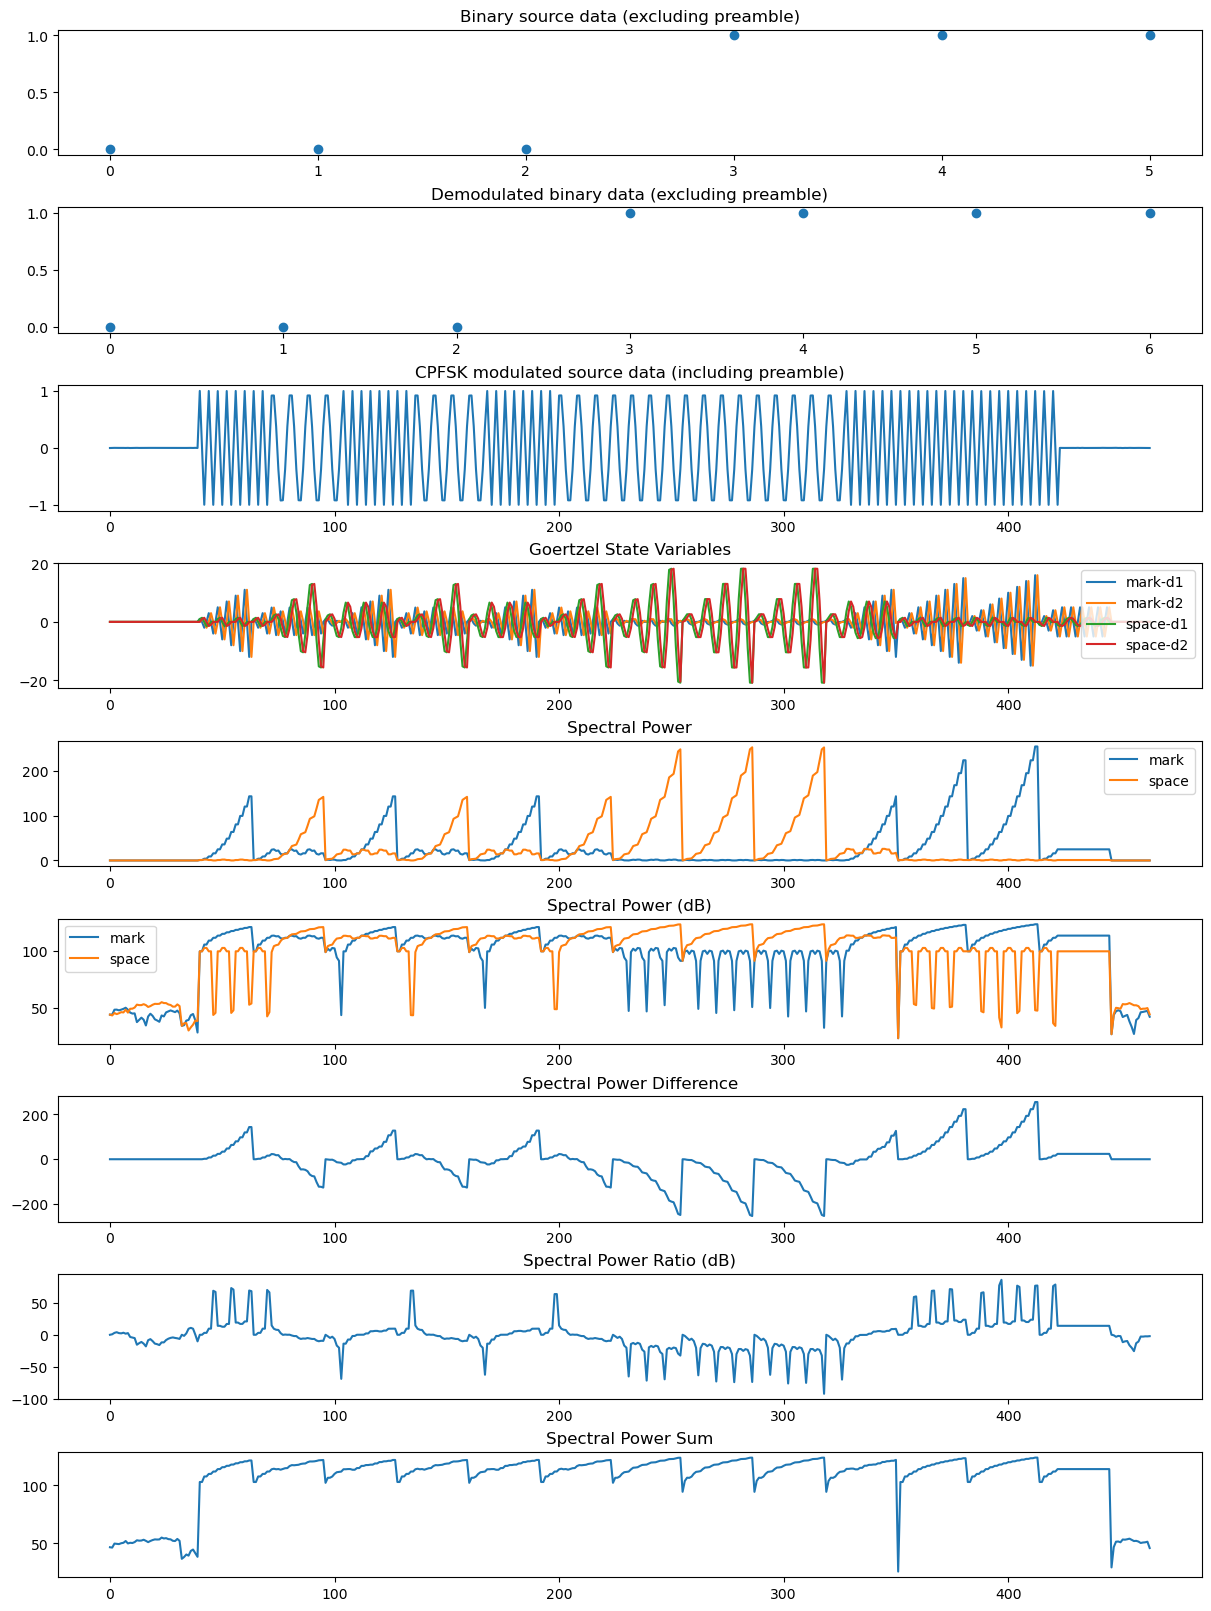

In [4]:
fig = plt.figure(figsize=(12, 16), dpi=100, layout='constrained')
axs = fig.subplot_mosaic([
    ['source'],
    ['output'],
    ['modulated'],
    ['state'],
    ['power'],
    ['power_db'],
    ['power_diff'],
    ['power_ratio'],
    ['total_power'],
])
axs['source'].plot(source, 'o')
axs['source'].set_title('Binary source data (excluding preamble)')
axs['output'].plot(states[np.logical_not(np.isnan(states['bit']))]['bit'], 'o')
axs['output'].set_title('Demodulated binary data (excluding preamble)')
axs['modulated'].plot(modulated)
axs['modulated'].set_title('CPFSK modulated source data (including preamble)')
axs['state'].plot(states['mark_d1'], label='mark-d1')
axs['state'].plot(states['mark_d2'], label='mark-d2')
axs['state'].plot(states['space_d1'], label='space-d1')
axs['state'].plot(states['space_d2'], label='space-d2')
axs['state'].legend()
axs['state'].set_title('Goertzel State Variables')
axs['power'].plot(states['mark_power'], label='mark')
axs['power'].plot(states['space_power'], label='space')
axs['power'].legend()
axs['power'].set_title('Spectral Power')
axs['power_db'].plot(to_decibel(states['mark_power'], 0), label='mark')
axs['power_db'].plot(to_decibel(states['space_power'], 0), label='space')
axs['power_db'].legend()
axs['power_db'].set_title('Spectral Power (dB)')
axs['power_diff'].plot(states['power_delta'])
axs['power_diff'].set_title('Spectral Power Difference')
axs['power_ratio'].plot(to_decibel(states['mark_power'], states['space_power']))
axs['power_ratio'].set_title('Spectral Power Ratio (dB)')
axs['total_power'].plot(to_decibel(states['total_power'], 0))
axs['total_power'].set_title('Spectral Power Sum')